<a href="https://colab.research.google.com/github/wilsonbedoya11/phyton/blob/pruebas/3_Ambos_Datas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np



In [59]:
dfhurto_motos = pd.read_csv("/content/drive/MyDrive/udea_practica/hurto_de_moto.csv")
dfhurto_personas = pd.read_csv("/content/drive/MyDrive/udea_practica/hurto_a_persona.csv")

<ipython-input-59-3d5f02d2bd85>:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  dfhurto_motos = pd.read_csv("/content/drive/MyDrive/udea_practica/hurto_de_moto.csv")
<ipython-input-59-3d5f02d2bd85>:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  dfhurto_personas = pd.read_csv("/content/drive/MyDrive/udea_practica/hurto_a_persona.csv")


In [ ]:
##Conviertir columna a fecha directamente, usando dataframe cargado
#dfhurto_personas['fecha_hecho'] = pd.to_datetime(dfhurto_personas['fecha_hecho'], errors='coerce')

#dfhurto_personas.info()

In [10]:
df_fecha = pd.Series(dfhurto_motos["fecha_hecho"])
df_fecha

,fecha_hecho
0,2017-01-01T23:00:00.000-05:00
1,2017-01-01T20:30:00.000-05:00
2,2017-01-01T07:00:00.000-05:00
3,2017-01-01T09:00:00.000-05:00
4,2017-01-01T16:30:00.000-05:00
...,...
86405,2023-11-30T08:15:00.000-05:00
86406,2023-11-30T08:30:00.000-05:00
86407,2023-11-30T16:00:00.000-05:00
86408,2023-11-30T20:13:00.000-05:00


In [11]:
dfhurto_personas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326489 entries, 0 to 326488
Data columns (total 36 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   fecha_hecho          326489 non-null  object 
 1   cantidad             326489 non-null  float64
 2   latitud              284545 non-null  float64
 3   longitud             284545 non-null  float64
 4   sexo                 326489 non-null  object 
 5   edad                 326489 non-null  int64  
 6   estado_civil         326489 non-null  object 
 7   grupo_actor          326489 non-null  object 
 8   actividad_delictiva  326489 non-null  object 
 9   parentesco           326489 non-null  object 
 10  ocupacion            326489 non-null  object 
 11  discapacidad         326489 non-null  object 
 12  grupo_especial       326489 non-null  object 
 13  medio_transporte     326489 non-null  object 
 14  nivel_academico      326489 non-null  object 
 15  testigo          

In [ ]:
type(df_fecha)

pandas.core.series.Series

In [12]:
df_fecha = df_fecha.str.split("T")
df_fecha

,fecha_hecho
0,"[2017-01-01, 23:00:00.000-05:00]"
1,"[2017-01-01, 20:30:00.000-05:00]"
2,"[2017-01-01, 07:00:00.000-05:00]"
3,"[2017-01-01, 09:00:00.000-05:00]"
4,"[2017-01-01, 16:30:00.000-05:00]"
...,...
86405,"[2023-11-30, 08:15:00.000-05:00]"
86406,"[2023-11-30, 08:30:00.000-05:00]"
86407,"[2023-11-30, 16:00:00.000-05:00]"
86408,"[2023-11-30, 20:13:00.000-05:00]"


In [13]:
#Separacion de fechas y horas
df_fecha = pd.DataFrame(df_fecha) # convierte la serie en dataframe
df_fecha = pd.DataFrame(df_fecha.fecha_hecho.values.tolist(), index=df_fecha.index)
df_fecha

,0,1
0,2017-01-01,23:00:00.000-05:00
1,2017-01-01,20:30:00.000-05:00
2,2017-01-01,07:00:00.000-05:00
3,2017-01-01,09:00:00.000-05:00
4,2017-01-01,16:30:00.000-05:00
...,...,...
86405,2023-11-30,08:15:00.000-05:00
86406,2023-11-30,08:30:00.000-05:00
86407,2023-11-30,16:00:00.000-05:00
86408,2023-11-30,20:13:00.000-05:00


In [14]:
#renombramos las columnas en un dataframe normal
df_fecha = df_fecha.rename(columns={0:"Fecha"})
df_fecha = df_fecha.rename(columns={1:"Hora"})
df_fecha

,Fecha,Hora
0,2017-01-01,23:00:00.000-05:00
1,2017-01-01,20:30:00.000-05:00
2,2017-01-01,07:00:00.000-05:00
3,2017-01-01,09:00:00.000-05:00
4,2017-01-01,16:30:00.000-05:00
...,...,...
86405,2023-11-30,08:15:00.000-05:00
86406,2023-11-30,08:30:00.000-05:00
86407,2023-11-30,16:00:00.000-05:00
86408,2023-11-30,20:13:00.000-05:00


In [15]:
# crear tipo de dato datatime
# se puede realizar calculos con las fechas
df_fecha_datatime = pd.to_datetime(df_fecha["Fecha"], format="%Y-%m-%d")
df_fecha_datatime

,Fecha
0,2017-01-01
1,2017-01-01
2,2017-01-01
3,2017-01-01
4,2017-01-01
...,...
86405,2023-11-30
86406,2023-11-30
86407,2023-11-30
86408,2023-11-30


In [16]:
df_fecha_datatime.min()

Timestamp('2003-01-01 00:00:00')

In [17]:
df_fecha_datatime.max()

Timestamp('2023-11-30 00:00:00')

In [18]:
df_fecha_datatime_mes = df_fecha_datatime.dt.month
df_fecha_datatime_mes

,Fecha
0,1
1,1
2,1
3,1
4,1
...,...
86405,11
86406,11
86407,11
86408,11


In [19]:
# identificar ideas de la semana
df_fecha_datatime_dia = df_fecha_datatime.dt.day_of_week
df_fecha_datatime_mes = pd.DataFrame(df_fecha_datatime_mes)

In [23]:
df_fecha_datatime_dia = pd.DataFrame(df_fecha_datatime_dia)
dfhurto_personas

,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
0,2017-01-01T01:00:00.000-05:00,1.0,6.299703,-75.582016,Mujer,33,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Vía pública,Doce de Octubre,Celular,Tecnología,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
1,2017-01-01T15:00:00.000-05:00,1.0,6.250917,-75.566160,Mujer,26,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Candelaria,Celular,Tecnología,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
2,2017-01-01T14:00:00.000-05:00,1.0,6.274836,-75.554909,Hombre,30,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Aranjuez,Celular,Tecnología,Mercancía,-1,Negro,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
3,2017-01-01T16:00:00.000-05:00,1.0,6.276236,-75.553533,Hombre,37,Casado(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Aranjuez,Celular,Tecnología,Mercancía,-1,Negro,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
4,2017-01-01T16:00:00.000-05:00,1.0,6.250339,-75.586914,Hombre,87,Casado(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Laureles,Billetera,Prendas de vestir y accesorios,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326484,2023-11-30T21:30:00.000-05:00,1.0,NaN,NaN,Hombre,29,Sin dato,Sin dato,Sin dato,Sin dato,...,Vía pública,Candelaria,Sin dato,Sin dato,Sin dato,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
326485,2023-11-30T23:00:00.000-05:00,1.0,NaN,NaN,Hombre,29,Sin dato,Sin dato,Sin dato,Sin dato,...,Vía pública,Poblado,Sin dato,Sin dato,Sin dato,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
326486,2023-11-30T23:00:00.000-05:00,1.0,NaN,NaN,Hombre,40,Sin dato,Sin dato,Sin dato,Sin dato,...,Bar o cantina,Candelaria,Sin dato,Sin dato,Sin dato,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
326487,2023-11-30T23:20:00.000-05:00,1.0,NaN,NaN,Hombre,29,Sin dato,Sin dato,Sin dato,Sin dato,...,Vía pública,Candelaria,Sin dato,Sin dato,Sin dato,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00


In [47]:
#hacer histograma sobre los dias
#histograma es una diagrama de frecuencia

#con la libreria:
import seaborn as sns # para estadistica
import matplotlib.pyplot as plt

sns.set_theme(style='darkgrid', palette='Set2', font='sans-serif')


(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.]),
 [Text(-1.0, 0, '−1'),
  Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7')])

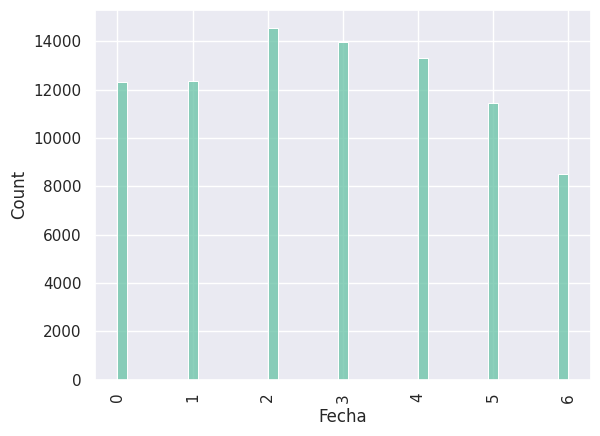

In [48]:
sns.histplot(data=df_fecha_datatime_dia, x="Fecha", stat="count")
plt.xticks(rotation = 90)

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4'),
  Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10'),
  Text(12.0, 0, '12'),
  Text(14.0, 0, '14')])

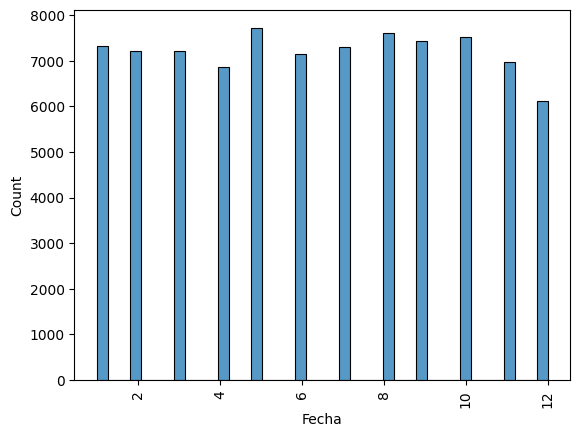

In [25]:
sns.histplot(data=df_fecha_datatime_mes, x="Fecha", stat="count")
plt.xticks(rotation = 90)

(array([2000. , 2002.5, 2005. , 2007.5, 2010. , 2012.5, 2015. , 2017.5,
        2020. , 2022.5, 2025. ]),
 [Text(2000.0, 0, '2000.0'),
  Text(2002.5, 0, '2002.5'),
  Text(2005.0, 0, '2005.0'),
  Text(2007.5, 0, '2007.5'),
  Text(2010.0, 0, '2010.0'),
  Text(2012.5, 0, '2012.5'),
  Text(2015.0, 0, '2015.0'),
  Text(2017.5, 0, '2017.5'),
  Text(2020.0, 0, '2020.0'),
  Text(2022.5, 0, '2022.5'),
  Text(2025.0, 0, '2025.0')])

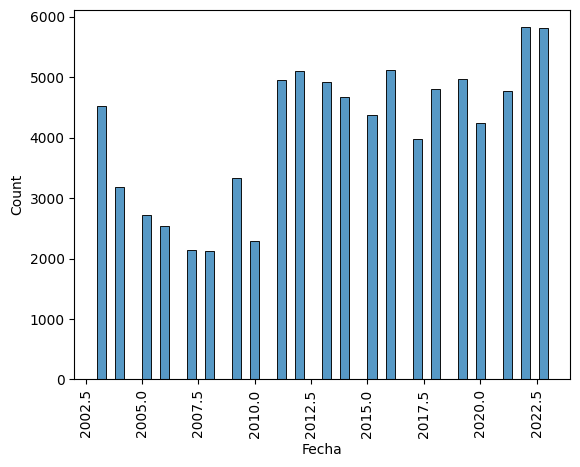

In [26]:
df_fecha_datatime_year = df_fecha_datatime.dt.year

df_fecha_datatime_year = pd.DataFrame(df_fecha_datatime_year)

sns.histplot(data=df_fecha_datatime_year, x="Fecha", stat="count")
plt.xticks(rotation = 90)


In [27]:
pd.unique(df_fecha_datatime_year["Fecha"])

array([2017, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2020, 2019, 2018, 2021, 2022, 2023],
      dtype=int32)

In [ ]:
# reconocimiento de patrones
# luego pasamos a compararlo con otros valores

In [28]:
df_fecha_agr =df_fecha.groupby("Fecha").size()
df_fecha_agr

,0
Fecha,
2003-01-01,10
2003-01-02,6
2003-01-03,8
2003-01-04,10
2003-01-05,6
...,...
2023-11-26,8
2023-11-27,9
2023-11-28,3


<Figure size 1200x600 with 0 Axes>

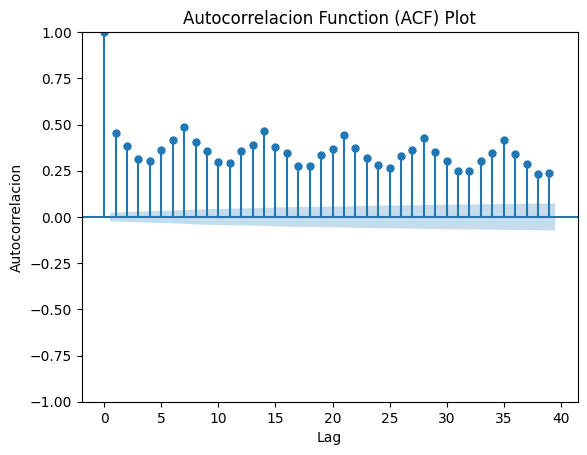

In [29]:
# calcular autocorrelacion de la serie de tiempo si los hechos de un dia dependen de otro

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,6))
plot_acf(df_fecha_agr)
plt.xlabel("Lag")  # escala de tiempo
plt.ylabel("Autocorrelacion")
plt.title("Autocorrelacion Function (ACF) Plot")
plt.show()

In [ ]:
# df_otro = df_nnn.str.strip()    quita el espacion en blanco al final de la palabra


In [30]:
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].str.lower()
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].str.strip()

dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 16 belen", "belén")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("cerro nutibara ins.", "cerro nutibara")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("facultad de minas u. nal", "facultad de minas u. nacional")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 10 la candelaria", "la candelaria")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 13 san javier", "san javier")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 3 manrique", "manrique")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 50 palmitas", "palmitas")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 6 doce de octubre", "doce de octubre")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 60 san cristobal", "san cristobal")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 7 robledo", "robledo")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 80 san antonio de prado", "san antonio de prado")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 9 buenos aires", "buenos aires")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("sin dato 90 santa elena", "santa elena")

dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área de expansión pajarito", "pajarito")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área de expansión calasanz", "calasanz")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área de expansión belén", "belén")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área de expansión altavista", "altavista")

dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área de expansión san antonio de prado", "san antonio de prado")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área urbana cgto. san antonio de prado", "san antonio de prado")
dfhurto_motos["nombre_barrio"] = dfhurto_motos["nombre_barrio"].replace("área urbana cgto. san cristóbal", "san cristóbal")

barrios = dfhurto_motos["nombre_barrio"].unique()
barrios.sort()
barrios

array(['aguas frias', 'aldea pablo vi', 'alejandro echavarría',
       'alejandría', 'alfonso lópez', 'altamira', 'altavista',
       'altavista sector central', 'altos del poblado', 'andalucía',
       'antonio nariño', 'aranjuez', 'asomadera no.1', 'asomadera no.2',
       'asomadera no.3', 'astorga', 'aures no.1', 'aures no.2',
       'b. cerro el volador', 'barrio caycedo', 'barrio colombia',
       'barrio colón', 'barrio cristóbal', 'barrios de jesús',
       'barro blanco', 'batallón cuarta brigada', 'batallón girardot',
       'belalcázar', 'belencito', 'bello horizonte', 'belén', 'berlin',
       'bermejal-los alamos', 'betania', 'blanquizal', 'bolivariana',
       'bomboná no.1', 'bomboná no.2', 'boqueron', 'bosques de san pablo',
       'boston', 'boyacá', 'brasilia', 'buenos aires',
       'buga patio bonito', 'calasania parte alta', 'calasanz',
       'calle nueva', 'campo alegre', 'campo amor', 'campo valdés no.1',
       'campo valdés no.2', 'caribe', 'carlos e. restrepo

In [ ]:
!pip install fuzzywuzzy

In [ ]:
import fuzzywuzzy
from fuzzywuzzy import process
import charset_normalizer

/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [ ]:
matches = fuzzywuzzy.process.extract("b", barrios, limit= 20, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
matches

[('belén', 40),
 ('boyacá', 33),
 ('u.p.b', 33),
 ('berlin', 29),
 ('boston', 29),
 ('caribe', 29),
 ('córdoba', 29),
 ('betania', 25),
 ('robledo', 25),
 ('boqueron', 22),
 ('brasilia', 22),
 ('guayabal', 22),
 ('pablo vi', 22),
 ('belalcázar', 20),
 ('belencito', 20),
 ('san pablo', 20),
 ('blanquizal', 18),
 ('el danubio', 18),
 ('el pesebre', 18),
 ('el poblado', 18)]

(array([4.76800e+03, 5.82010e+04, 1.36697e+05, 7.47020e+04, 3.62320e+04,
        1.33920e+04, 2.27400e+03, 2.20000e+02, 0.00000e+00, 3.00000e+00]),
 array([ -1. ,  11.2,  23.4,  35.6,  47.8,  60. ,  72.2,  84.4,  96.6,
        108.8, 121. ]),
 <BarContainer object of 10 artists>)

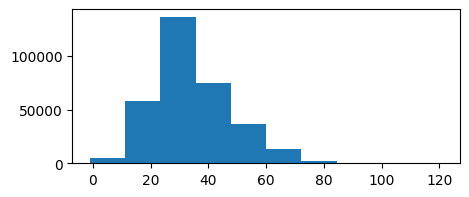

In [ ]:
#histrograma de hurto personas por edades
plt.figure(figsize=(5,2))
plt.title="Hurtos por edad"
plt.hist(dfhurto_personas["edad"])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Caminata'),
  Text(1, 0, 'Taxi'),
  Text(2, 0, 'Motocicleta'),
  Text(3, 0, 'Automóvil'),
  Text(4, 0, 'Metro'),
  Text(5, 0, 'Bicicleta'),
  Text(6, 0, 'Autobus'),
  Text(7, 0, 'Motocicleta con parrillero'),
  Text(8, 0, 'Sin dato'),
  Text(9, 0, 'Planeador')])

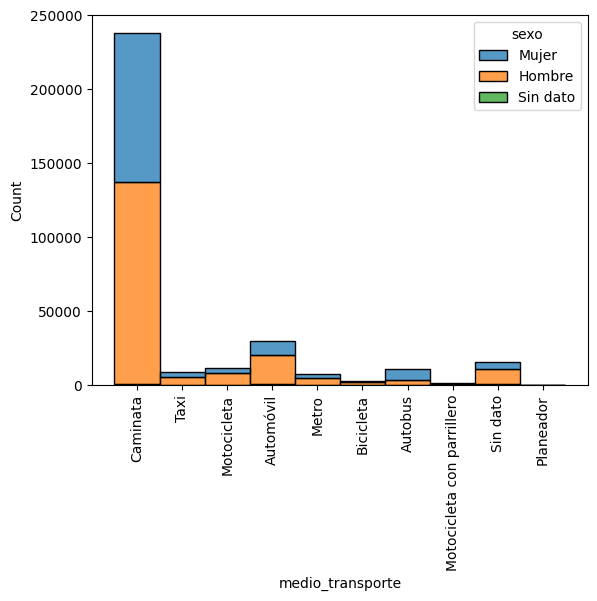

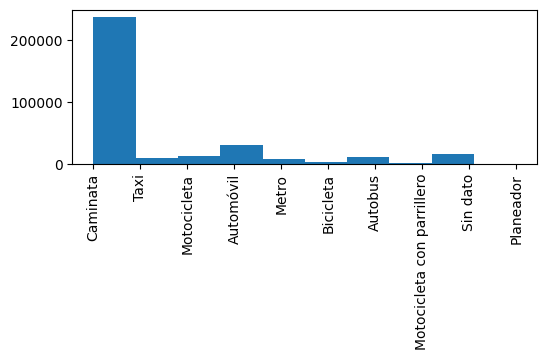

In [ ]:
##crear histograma por medio de trasponrte segmentado por sexo
import seaborn as sns

sns.histplot(data=dfhurto_personas,   #dataframe
             x="medio_transporte",  #datos del eje x
             hue="sexo",            # categorias que se visualizan
             multiple="stack")      #apilar categorica
plt.xticks(rotation=90)


plt.figure(figsize=(6,2))
plt.hist(dfhurto_personas["medio_transporte"])
plt.xticks(rotation=90)

In [ ]:
dfhurto_personas[dfhurto_personas["medio_transporte"] == "Planeador"]


,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
18332,2017-08-09T00:30:00.000-05:00,1.0,6.208773,-75.568194,Hombre,28,Soltero(a),Sin dato,Sin dato,Sin dato,...,Parque,Poblado,Peso,"Dinero, joyas, piedras preciosas y título valor",Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
18372,2017-08-09T00:30:00.000-05:00,1.0,6.208773,-75.568194,Hombre,28,Soltero(a),Sin dato,Sin dato,Sin dato,...,Parque,Poblado,Celular,Tecnología,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
45552,2017-11-28T07:00:00.000-05:00,1.0,6.217739,-75.586662,Mujer,26,Divorciado(a),Sin dato,Sin dato,Sin dato,...,Aeropuerto,Belén,Peso,"Dinero, joyas, piedras preciosas y título valor",Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
45553,2017-11-28T09:00:00.000-05:00,1.0,6.216197,-75.589291,Mujer,26,Divorciado(a),Sin dato,Sin dato,Sin dato,...,Aeropuerto,Belén,Peso,"Dinero, joyas, piedras preciosas y título valor",Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
101312,2016-05-07T14:00:00.000-05:00,1.0,6.221405,-75.588510,Mujer,42,Casado(a),Sin dato,Sin dato,Sin dato,...,Aeropuerto,Belén,Maletín,Otros elementos,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
124205,2019-04-06T13:00:00.000-05:00,1.0,6.249886,-75.570742,Mujer,27,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Local comercial,Candelaria,Sin dato tecnología,Tecnología,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
181394,2020-10-27T11:30:00.000-05:00,1.0,6.220831,-75.588514,Mujer,34,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Aeropuerto,Belén,Peso,"Dinero, joyas, piedras preciosas y título valor",Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
182543,2020-11-10T09:30:00.000-05:00,1.0,6.249718,-75.588765,Mujer,63,Casado(a),Sin dato,Sin dato,Sin dato,...,Paradero de bus,Laureles,Celular,Tecnología,Mercancía,-1,Azul,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
221100,2018-10-25T06:40:00.000-05:00,1.0,6.239003,-75.571690,Mujer,31,Casado(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Candelaria,Celular,Tecnología,Mercancía,-1,Oro,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
225254,2021-01-04T15:00:00.000-05:00,1.0,6.219120,-75.586050,Hombre,24,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Belén,Celular,Tecnología,Mercancía,-1,Negro,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Arma cortopunzante'),
  Text(1, 0, 'No'),
  Text(2, 0, 'Arma de fuego'),
  Text(3, 0, 'Objeto contundente'),
  Text(4, 0, 'Escopolamina'),
  Text(5, 0, 'Sin dato'),
  Text(6, 0, 'Llave maestra'),
  Text(7, 0, 'Perro'),
  Text(8, 0, 'Palanca'),
  Text(9, 0, 'Tóxico o Químico')])

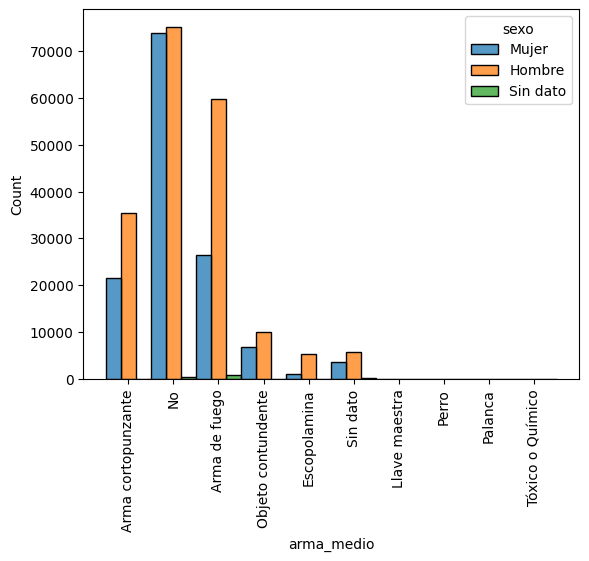

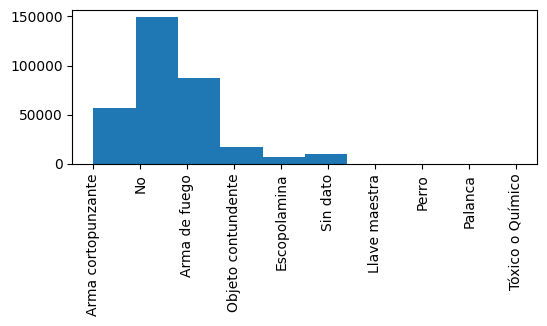

In [ ]:
sns.histplot(data=dfhurto_personas,   #dataframe
             x="arma_medio",  #datos del eje x
             hue="sexo",            # categorias que se visualizan
             multiple="dodge")      #apilar categorica = stack, paralelos = dodge
plt.xticks(rotation=90)


plt.figure(figsize=(6,2))
plt.hist(dfhurto_personas["arma_medio"])
plt.xticks(rotation=90)

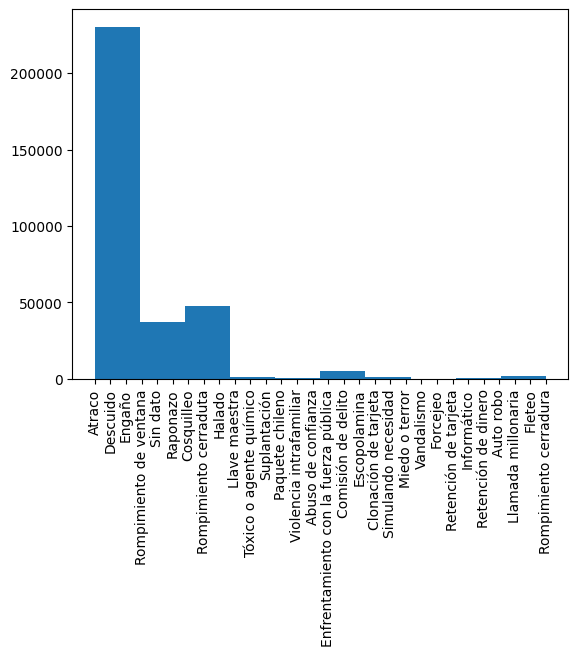

In [ ]:
#hist sobre modalidad del hurto
plt.hist(dfhurto_personas["modalidad"])
plt.xticks(rotation=90)
plt.show()

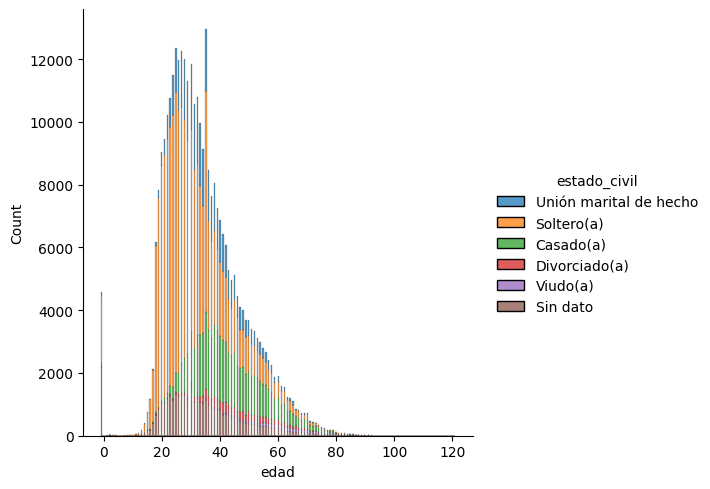

In [ ]:
#diagrama de dispersion
sns.displot(
    data= dfhurto_personas,
    x="edad",
    hue="estado_civil",   #medio_transporte
    multiple="stack"
)
plt.savefig('histograma.svg') #guardar

In [ ]:
re = eval('45+45')
re

90

In [7]:
pagina = pd.read_html('https://datosmacro.expansion.com/estado/gasto/colombia')
pagina[0]

df_datos = pd.DataFrame(pagina[0])
df_datos["Fecha"].max()

2023

<ipython-input-82-f459174eda2c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


TypeError: 'str' object is not callable

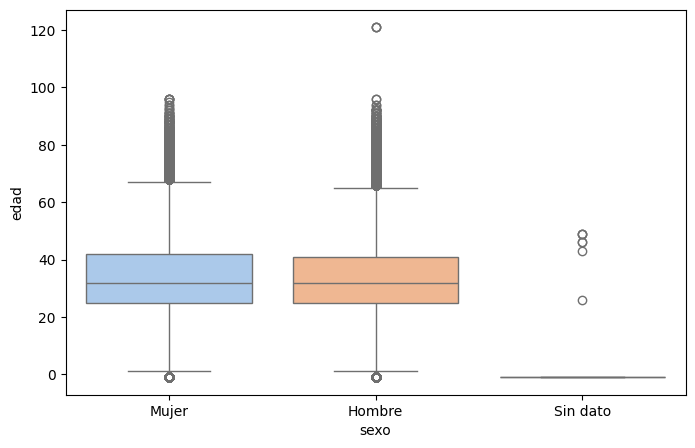

In [ ]:
#grafica de cajas para relaciones entre sexo y edad
plt.figure(figsize=(8,5))
sns.boxplot(
    x=dfhurto_personas["sexo"],
    y=dfhurto_personas["edad"],
    palette='pastel')
plt.title(
    'Distribución en hurto de personas para edades por sexo',
    fontsize=14)
plt.xlabel(
    "Sexo",
    fontsize=12)
plt.ylabel(
    "Edad",
    fontsize=12)
plt.xticks(rotation=45)
plt.show()
plt.savefig("Dist_edad_sexo.svg")


In [ ]:
# intercuartil = q3-q1    (75 - 25)
# valor superior = (intercuartil * 1.25)+q3
# valor inferior = (intercuartil * -1.25) -q1

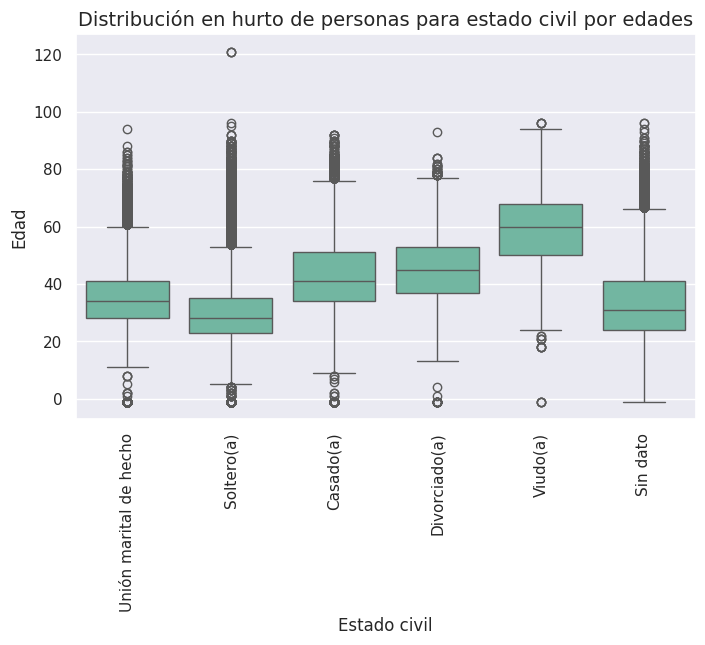

In [49]:
#
plt.figure(figsize=(8,5))
sns.boxplot(
    x=dfhurto_personas['estado_civil'],
    y=dfhurto_personas['edad'],
    #palette="pastel"
    )
plt.title(
    'Distribución en hurto de personas para estado civil por edades',
    fontsize=14)
plt.xlabel('Estado civil', fontsize=12)
plt.ylabel('Edad', fontsize=12)
plt.xticks(rotation=90)
plt.show()

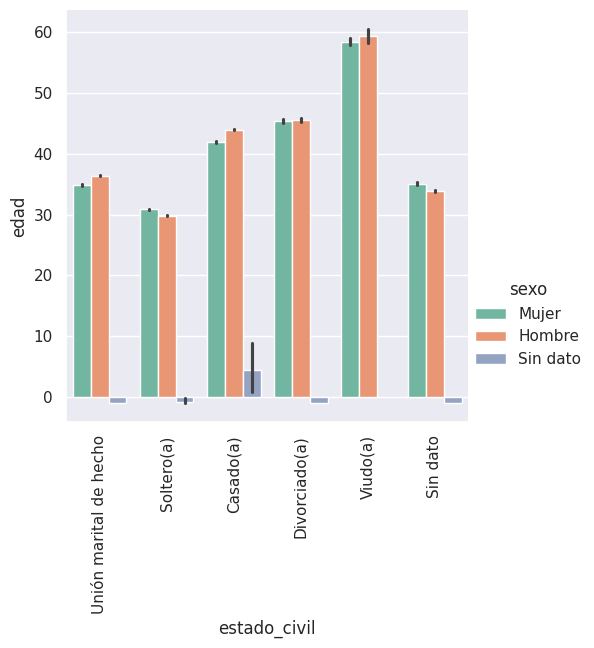

In [50]:
sns.catplot(
    data=dfhurto_personas,
    x='estado_civil',
    y='edad',
    hue='sexo',
    kind='bar')
plt.xticks(rotation=90)
plt.show()

<Figure size 4000x1000 with 0 Axes>

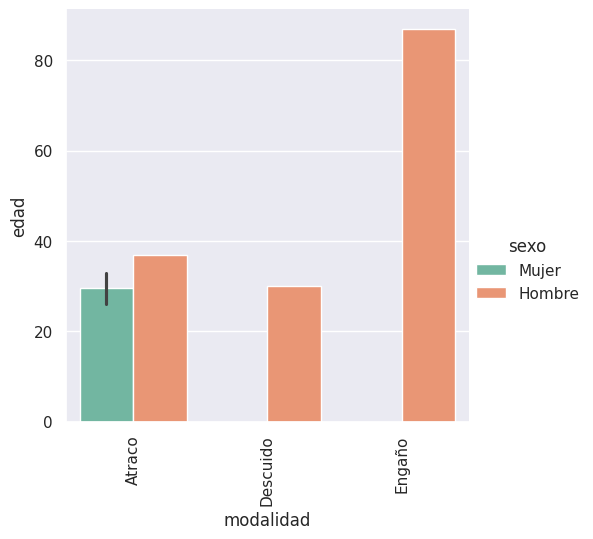

In [60]:
plt.figure(figsize=(40,10))
sns.catplot(
    data=dfhurto_personas.head(),
    x='modalidad',
    y='edad',
    hue='sexo',
    kind='bar')
plt.xticks(rotation=90)
plt.show()